In [1]:
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np

In [2]:
def calculate_index_1(data):
    return (data >> 6) % 8

In [3]:
def calculate_index_2(data):
    # 1. 右移 12 位
    shifted_data = data >> 12
    
    # 2. 提取连续的 3 个 3位 块
    # 使用 0x7 (二进制 111) 作为掩码来提取 3 位
    part_a = (shifted_data >> 0) & 0x7  # 第 0-2 位
    part_b = (shifted_data >> 3) & 0x7  # 第 3-5 位
    part_c = (shifted_data >> 6) & 0x7  # 第 6-8 位
    
    # 3. 连续异或 3 次（即 A xor B xor C）
    index_result = part_a ^ part_b ^ part_c
    
    return index_result

In [4]:
def analyze_ptw_trace(file_path):
    addr1_results = []
    addr2_results = []
    target_mmu = None

    try:
        with open(file_path, 'r') as f:
            for line in f:
                line = line.strip()
                if not line: continue
                
                parts = [p.strip() for p in line.split(',')]
                if len(parts) < 3: continue
                
                mmu_name, addr1_str, addr2_str = parts[0], parts[1], parts[2]

                # 自动锁定第一个出现的 MMU 设备
                if target_mmu is None:
                    target_mmu = mmu_name
                    print(f"[*] 正在提取第一个 MMU 的数据: {target_mmu}")

                # 只处理该 MMU 的数据
                if mmu_name == target_mmu:
                    # 转换 16 进制地址 (处理 0x 前缀)
                    addr1 = int(addr1_str, 16)
                    addr2 = int(addr2_str, 16)

                    # 计算逻辑: 
                    # 1. 右移 6 位 (>> 6) 去掉 64B 的 Offset 得到 Cache Line Index
                    # 2. 对 8 取模 (%) 得到直方图分布
                    addr1_results.append(calculate_index_1(addr1))
                    addr2_results.append(calculate_index_2(addr2))
        
        return addr1_results, addr2_results, target_mmu

    except FileNotFoundError:
        print(f"错误：找不到文件 '{file_path}'，请确保它在当前文件夹下。")
        return None, None, None

[*] 正在提取第一个 MMU 的数据: GPU1.chiplet_00.GPC_00.BaselineMMU


/var/folders/m4/f09vrxfd6y7chcgqpznxzyyw0000gn/T/ipykernel_69743/301994769.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['{:.0%}'.format(x) for x in ax.get_yticks()])
/var/folders/m4/f09vrxfd6y7chcgqpznxzyyw0000gn/T/ipykernel_69743/301994769.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['{:.0%}'.format(x) for x in ax.get_yticks()])


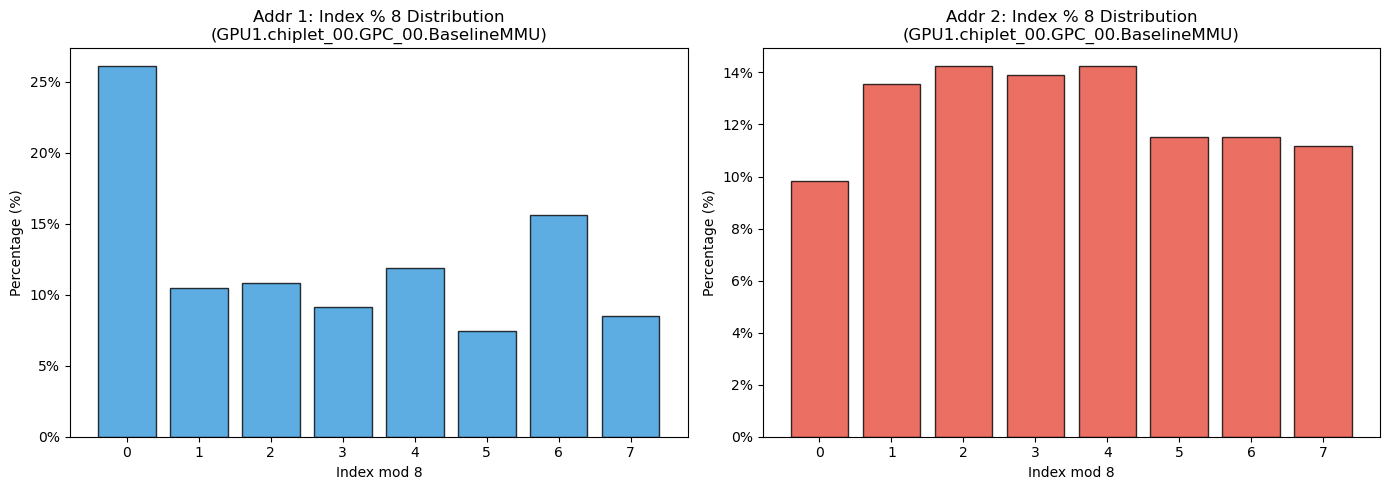

In [5]:
# 执行分析
file_name = '/Users/chenzihang/Develop/CachePWQ/simulator/mgpusim/samples/matrixtranspose/ptw.trace'
data1, data2, mmu_label = analyze_ptw_trace(file_name)

if data1 is not None and len(data1) > 0:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # 设置统一的 y 轴标签格式为百分比
    def plot_percentage_hist(ax, data, title, color):
        # 计算每个值的占比
        counts = Counter(data)
        total = sum(counts.values())
        # 补全 0-7 的 key，确保 x 轴完整
        probs = [counts.get(i, 0) / total for i in range(8)]
        
        ax.bar(range(8), probs, color=color, edgecolor='black', alpha=0.8)
        ax.set_title(title)
        ax.set_xticks(range(8))
        ax.set_xlabel('Index mod 8')
        ax.set_ylabel('Percentage (%)')
        # 将 y 轴刻度转换为百分比显示
        ax.set_yticklabels(['{:.0%}'.format(x) for x in ax.get_yticks()])

    # 绘制两张图
    plot_percentage_hist(ax1, data1, f'Addr 1: Index % 8 Distribution\n({mmu_label})', '#3498db')
    plot_percentage_hist(ax2, data2, f'Addr 2: Index % 8 Distribution\n({mmu_label})', '#e74c3c')

    plt.tight_layout()
    plt.show()
else:
    print("没有提取到有效数据，请检查文件格式。")